# Hands On Sesi 5

Nama : Nabiel Izzullah Pansuri  
NIM: 250401020113  
Kelas: IF403

In [50]:
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec

In [70]:
#Loading Dataset
df = sns.load_dataset('flights')

#Getting shape and data types of dataset
print(df.shape, '\n', df.dtypes, '\n', df.describe().round(2))

(144, 3) 
 year             int64
month         category
passengers       int64
dtype: object 
           year  passengers
count   144.00      144.00
mean   1954.50      280.30
std       3.46      119.97
min    1949.00      104.00
25%    1951.75      180.00
50%    1954.50      265.50
75%    1957.25      360.50
max    1960.00      622.00


In [77]:
#get Head of dataset
df.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [72]:
#Average of passenger (all time round)
print(df['passengers'].mean().__round__(2))

280.3


1520
5714


C:\Users\nizzu\AppData\Local\Temp\ipykernel_17372\1282551639.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='passengers', ax=ax2, palette='Set2')


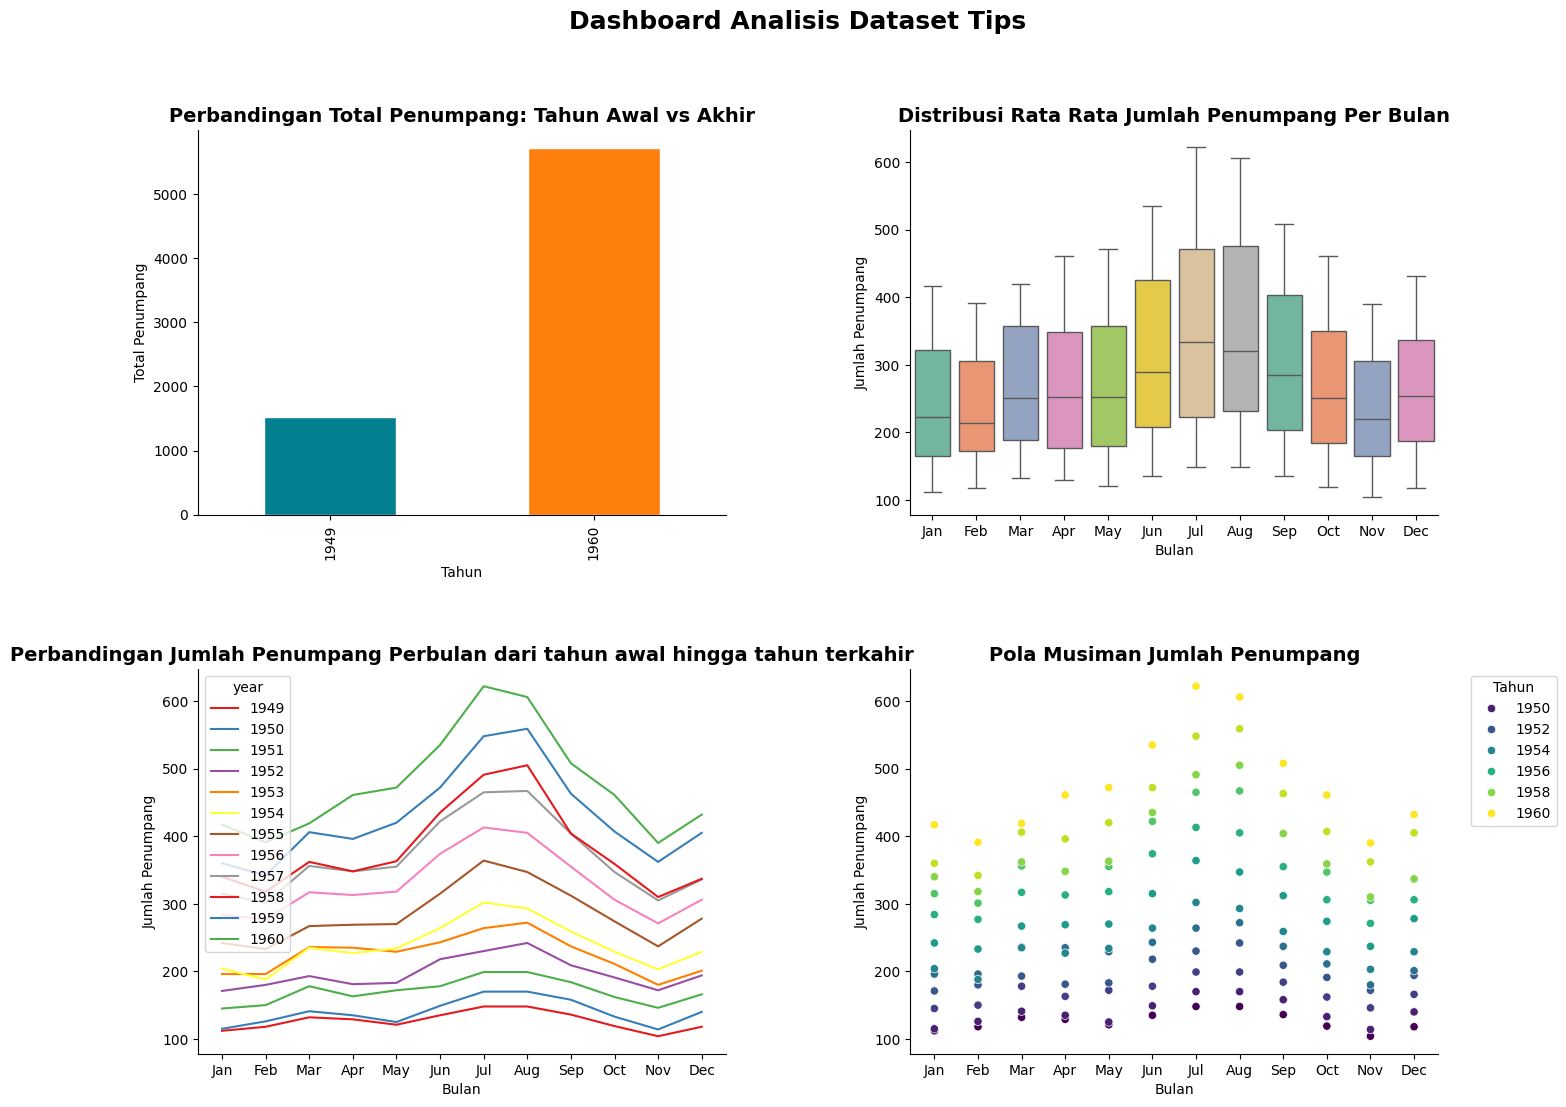

In [101]:
# ── 2. SETUP FIGURE LAYOUT ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Dashboard Analisis Dataset Tips',
fontsize=18, fontweight='bold', y=0.98)
# Grid 2 x 2 subplot
gs = gridspec.GridSpec(2, 2, figure=fig,
hspace=0.4, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0]) # kiri atas
ax2 = fig.add_subplot(gs[0, 1]) # kanan atas
ax3 = fig.add_subplot(gs[1, 0]) # kiri bawah
ax4 = fig.add_subplot(gs[1, 1]) # kanan bawah

first_year = df['year'].min()
last_year = df['year'].max()

total_first_year = df[df['year'] == first_year]['passengers'].sum()
total_last_year = df[df['year'] == last_year]['passengers'].sum()

print(total_first_year)
print(total_last_year)

yearly_total = df.groupby('year')['passengers'].sum()
comparison = yearly_total.loc[[first_year, last_year]]

comparison.plot(
    kind='bar',
    ax=ax1,
    color=['#028090', '#ff7f0e'],
    edgecolor='white'
)

ax1.set_title('Perbandingan Total Penumpang: Tahun Awal vs Akhir', fontsize=14, fontweight='bold')
ax1.set_xlabel('Tahun')
ax1.set_ylabel('Total Penumpang')
ax1.spines[['top','right']].set_visible(False)

ax2.set_title('Distribusi Rata Rata Jumlah Penumpang Per Bulan', fontsize=14, fontweight='bold')
ax2.set_xlabel('Bulan'); ax2.set_ylabel('Jumlah Penumpang')
sns.boxplot(data=df, x='month', y='passengers', ax=ax2, palette='Set2')
ax2.spines[['top','right']].set_visible(False)

ax3.set_title('Perbandingan Jumlah Penumpang Perbulan dari tahun awal hingga tahun terkahir', fontsize=14, fontweight='bold')
sns.lineplot(data=df, x='month', y='passengers', hue='year', ax=ax3, palette='Set1')
ax3.set_xlabel('Bulan'); ax3.set_ylabel('Jumlah Penumpang')
ax3.spines[['top','right']].set_visible(False)

sns.scatterplot(
    data=df,
    x='month',
    y='passengers',
    hue='year',
    palette='viridis',
    ax=ax4
)

ax4.set_title('Pola Musiman Jumlah Penumpang', fontsize=14, fontweight='bold')
ax4.set_xlabel('Bulan')
ax4.set_ylabel('Jumlah Penumpang')
ax4.legend(title='Tahun', bbox_to_anchor=(1.05, 1), loc='upper left')
ax4.spines[['top','right']].set_visible(False)
plt.show()


# Kesimpulan
Berdasarkan visualisasi grafik diatas, ditemukan bahwa
1. Terjadi kenaikan penumpang sebesar 26% dari tahun pertama hingga tahun terakhir data ini diambil (dari 1520 penumpang, menjadi 5714).
2. Tren jumlah penumpang cenderung fluktuatif.
3. Pola penumpang adalah musiman (seasonal), di mana jumlah penumpang cenderung meningkat pada pertengahan tahun (sekitar bulan Juni–Agustus), cenderung naik pada awal dan akhir tahun, juga cenderung turun pada bulan ke-2 dan ke-11 (Februari dan November). 
4. Variasi jumlah penumpang lebih dipengaruhi oleh pola musiman dibanding perubahan antar tahun.